In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Cloud Cost Optimization Analytics")
print("Python environment is working!")

Cloud Cost Optimization Analytics
Python environment is working!


In [19]:
hdfs_output = r"C:\Users\kumardereddy\OneDrive\Desktop\BigData\hadoop-3.2.2\cloud-cost-mapreduce"

print("MapReduce output:")

MapReduce output:


In [20]:
import subprocess

result = subprocess.run(
    [
        r"C:\Users\kumardereddy\OneDrive\Desktop\BigData\hadoop-3.2.2\bin\hdfs.cmd",
        "dfs",
        "-cat",
        "/cloud_cost_project/output/part-r-00000"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

AWS_EC2	150.5
Azure_Blob	45.2



In [21]:
data = []

for line in result.stdout.strip().splitlines():
    service, cost = line.split()
    data.append([service, float(cost)])

df = pd.DataFrame(data, columns=["Cloud_Service", "Total_Cost"])

df

,Cloud_Service,Total_Cost
0,AWS_EC2,150.5
1,Azure_Blob,45.2


In [22]:
print("Total Cloud Cost:", df["Total_Cost"].sum())
print("Average Cloud Cost:", df["Total_Cost"].mean())
print("Highest Cost Service:", df.loc[df["Total_Cost"].idxmax(), "Cloud_Service"])

Total Cloud Cost: 195.7
Average Cloud Cost: 97.85
Highest Cost Service: AWS_EC2


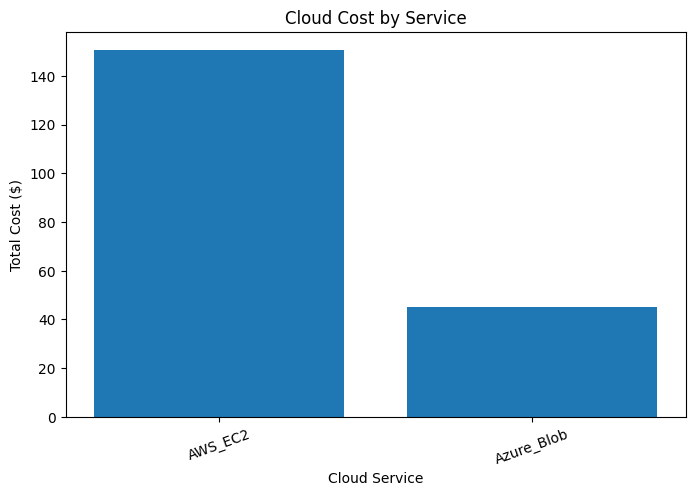

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(df["Cloud_Service"], df["Total_Cost"])

plt.title("Cloud Cost by Service")
plt.xlabel("Cloud Service")
plt.ylabel("Total Cost ($)")
plt.xticks(rotation=20)

plt.show()

In [3]:
df = pd.read_csv(
    r"C:\Users\kumardereddy\OneDrive\Desktop\BigData\cloud-cost-optimization\data\raw\cloud_cost_data.csv"
)

df.head(10)

,Account_ID,Cloud_Provider,Service,Region,Usage_Date,Usage_Hours,Data_Transfer_GB,Storage_GB,Monthly_Cost
0,ACC-127,GCP,Compute Engine,us-central1,2026-02-05,300,230.98,1478.21,135.77
1,ACC-114,AWS,EC2,us-east-1,2026-01-28,288,510.30,72.54,74.85
2,ACC-106,Azure,Azure SQL,eastus,2026-01-21,482,346.85,327.85,225.40
3,ACC-140,Azure,Azure SQL,centralindia,2026-02-03,94,732.43,1081.73,102.80
4,ACC-106,GCP,Cloud SQL,asia-south1,2026-01-25,121,55.37,471.24,32.60
5,ACC-104,Azure,Azure SQL,westus,2026-03-23,423,171.03,723.44,175.86
6,ACC-120,GCP,Cloud Storage,asia-south1,2026-02-01,217,467.64,554.50,129.28
7,ACC-141,AWS,S3,us-east-1,2026-02-10,460,275.06,437.75,226.80
8,ACC-137,Azure,Functions,centralindia,2026-02-28,196,272.23,508.32,81.09
9,ACC-143,Azure,Azure SQL,eastus,2026-01-18,571,498.58,1516.45,262.79


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account_ID        500 non-null    str    
 1   Cloud_Provider    500 non-null    str    
 2   Service           500 non-null    str    
 3   Region            500 non-null    str    
 4   Usage_Date        500 non-null    str    
 5   Usage_Hours       500 non-null    int64  
 6   Data_Transfer_GB  500 non-null    float64
 7   Storage_GB        500 non-null    float64
 8   Monthly_Cost      500 non-null    float64
dtypes: float64(3), int64(1), str(5)
memory usage: 35.3 KB


In [5]:
df.describe()

,Usage_Hours,Data_Transfer_GB,Storage_GB,Monthly_Cost
count,500.000000,500.000000,500.000000,500.00000
mean,402.578000,487.467300,998.512280,158.79122
std,194.501696,281.900401,566.985507,71.45838
min,52.000000,14.780000,20.390000,30.54000
25%,227.000000,248.655000,493.482500,107.44750
50%,423.000000,469.765000,1054.765000,149.40000
75%,569.500000,712.735000,1470.275000,202.80750
max,719.000000,999.910000,1997.480000,384.22000


In [6]:
df["Cloud_Provider"].value_counts()

Cloud_Provider
GCP      175
AWS      171
Azure    154
Name: count, dtype: int64

In [7]:
provider_cost = df.groupby("Cloud_Provider")["Monthly_Cost"].sum().sort_values(ascending=False)

provider_cost

Cloud_Provider
GCP      27270.13
AWS      26290.84
Azure    25834.64
Name: Monthly_Cost, dtype: float64

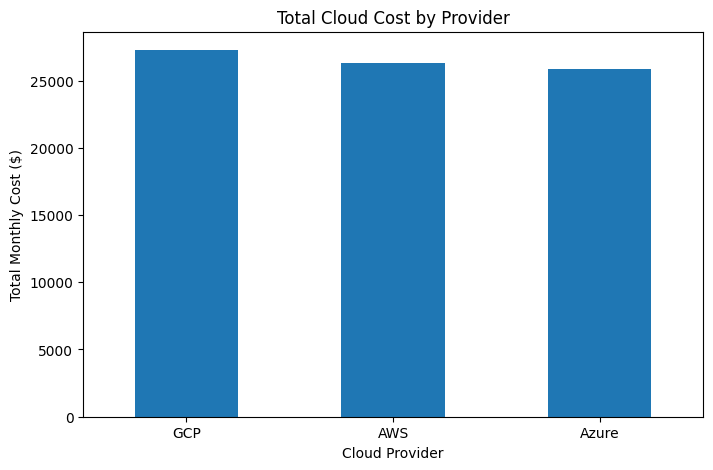

In [8]:
provider_cost.plot(kind="bar", figsize=(8, 5))

plt.title("Total Cloud Cost by Provider")
plt.xlabel("Cloud Provider")
plt.ylabel("Total Monthly Cost ($)")
plt.xticks(rotation=0)
plt.show()

In [9]:
service_cost = df.groupby("Service")["Monthly_Cost"].sum().sort_values(ascending=False)

service_cost

Service
Azure SQL           7696.54
S3                  7462.07
Cloud Storage       7192.12
Virtual Machines    7161.47
EC2                 7008.81
Cloud SQL           6833.18
Cloud Functions     6681.08
Compute Engine      6563.75
RDS                 6082.90
Lambda              5737.06
Blob Storage        5671.64
Functions           5304.99
Name: Monthly_Cost, dtype: float64

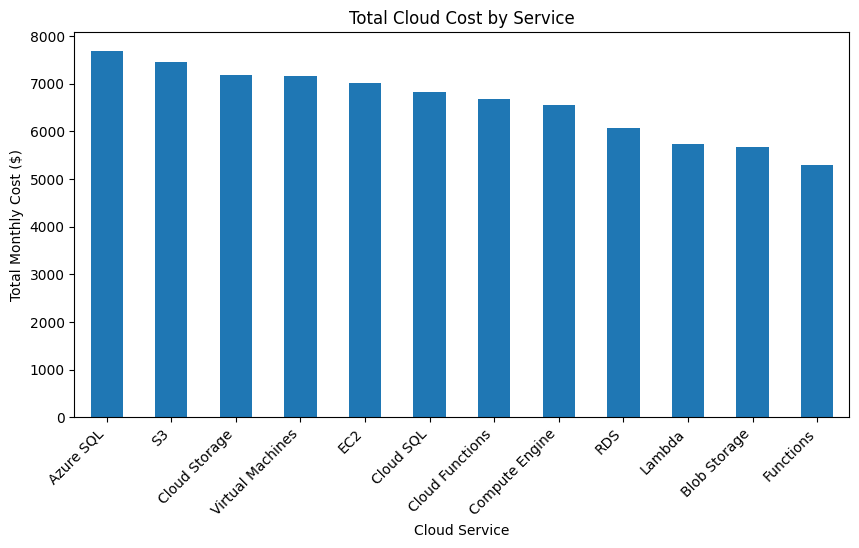

In [10]:
service_cost.plot(kind="bar", figsize=(10, 5))

plt.title("Total Cloud Cost by Service")
plt.xlabel("Cloud Service")
plt.ylabel("Total Monthly Cost ($)")
plt.xticks(rotation=45, ha="right")

plt.show()

In [11]:
account_cost = df.groupby("Account_ID")["Monthly_Cost"].sum().sort_values(ascending=False)

account_cost.head(10)

Account_ID
ACC-105    2879.70
ACC-132    2549.28
ACC-140    2498.77
ACC-149    2493.75
ACC-124    2359.50
ACC-143    2293.85
ACC-110    2263.54
ACC-127    2152.41
ACC-119    2114.16
ACC-128    2069.05
Name: Monthly_Cost, dtype: float64

In [12]:
account_cost = df.groupby("Account_ID")["Monthly_Cost"].sum().sort_values(ascending=False)

account_cost.head(10)

Account_ID
ACC-105    2879.70
ACC-132    2549.28
ACC-140    2498.77
ACC-149    2493.75
ACC-124    2359.50
ACC-143    2293.85
ACC-110    2263.54
ACC-127    2152.41
ACC-119    2114.16
ACC-128    2069.05
Name: Monthly_Cost, dtype: float64

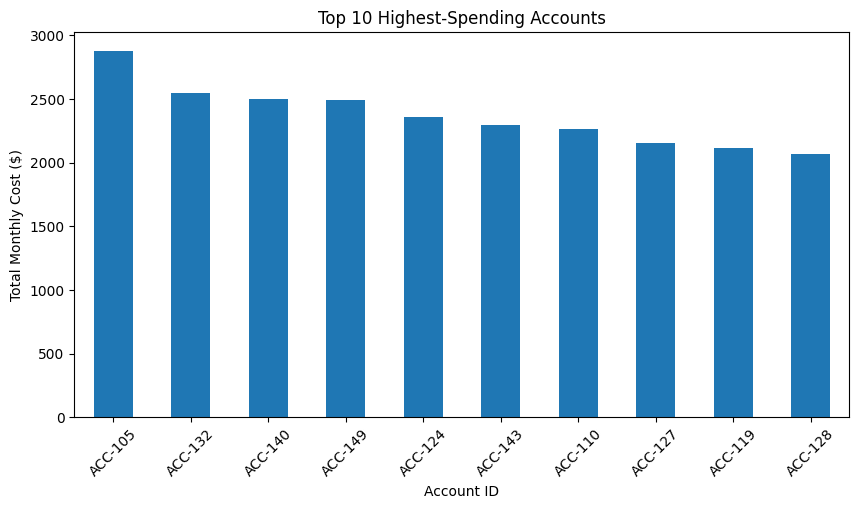

In [13]:
top_accounts = account_cost.head(10)

top_accounts.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Highest-Spending Accounts")
plt.xlabel("Account ID")
plt.ylabel("Total Monthly Cost ($)")
plt.xticks(rotation=45)

plt.show()

In [14]:
avg_provider_cost = df.groupby("Cloud_Provider")["Monthly_Cost"].mean().sort_values(ascending=False)

avg_provider_cost

Cloud_Provider
Azure    167.757403
GCP      155.829314
AWS      153.747602
Name: Monthly_Cost, dtype: float64

In [15]:
provider_service_cost = df.groupby(
    ["Cloud_Provider", "Service"]
)["Monthly_Cost"].sum().sort_values(ascending=False)

provider_service_cost.head(10)

Cloud_Provider  Service         
Azure           Azure SQL           7696.54
AWS             S3                  7462.07
GCP             Cloud Storage       7192.12
Azure           Virtual Machines    7161.47
AWS             EC2                 7008.81
GCP             Cloud SQL           6833.18
                Cloud Functions     6681.08
                Compute Engine      6563.75
AWS             RDS                 6082.90
                Lambda              5737.06
Name: Monthly_Cost, dtype: float64

In [16]:
top_expensive = df.sort_values(
    "Monthly_Cost", ascending=False
)

top_expensive.head(10)

,Account_ID,Cloud_Provider,Service,Region,Usage_Date,Usage_Hours,Data_Transfer_GB,Storage_GB,Monthly_Cost
404,ACC-135,AWS,EC2,us-east-1,2026-03-27,630,853.73,1705.75,384.22
159,ACC-140,Azure,Virtual Machines,centralindia,2026-02-15,679,998.17,563.62,384.07
10,ACC-146,Azure,Virtual Machines,westus,2026-02-18,660,996.16,1067.65,371.09
262,ACC-105,Azure,Blob Storage,westus,2026-01-14,719,753.83,609.46,369.23
331,ACC-106,AWS,Lambda,us-east-1,2026-01-19,630,592.05,1521.59,363.15
202,ACC-143,Azure,Azure SQL,westus,2026-03-31,612,913.67,1519.55,354.01
373,ACC-132,AWS,Lambda,us-west-2,2026-01-05,620,553.61,1655.30,332.86
249,ACC-105,Azure,Functions,westus,2026-03-28,652,693.53,318.47,330.17
104,ACC-106,GCP,Cloud Functions,asia-south1,2026-02-08,714,414.21,296.76,328.89
71,ACC-119,AWS,EC2,ap-south-1,2026-02-23,670,600.17,1244.47,325.55


In [17]:
provider_service = df.groupby(
    ["Cloud_Provider", "Service"]
)["Monthly_Cost"].sum().reset_index()

provider_service.loc[
    provider_service.groupby("Cloud_Provider")["Monthly_Cost"].idxmax()
]

,Cloud_Provider,Service,Monthly_Cost
3,AWS,S3,7462.07
4,Azure,Azure SQL,7696.54
10,GCP,Cloud Storage,7192.12


In [18]:
df["Cost_Per_Hour"] = df["Monthly_Cost"] / df["Usage_Hours"]

df[["Account_ID", "Cloud_Provider", "Service", "Usage_Hours", "Monthly_Cost", "Cost_Per_Hour"]].sort_values(
    "Cost_Per_Hour", ascending=False
).head(10)

,Account_ID,Cloud_Provider,Service,Usage_Hours,Monthly_Cost,Cost_Per_Hour
97,ACC-114,Azure,Virtual Machines,100,166.90,1.669000
270,ACC-112,AWS,EC2,66,100.42,1.521515
32,ACC-113,GCP,Cloud Storage,92,139.32,1.514348
293,ACC-106,AWS,RDS,59,86.03,1.458136
281,ACC-149,AWS,EC2,90,121.30,1.347778
164,ACC-135,AWS,Lambda,139,182.26,1.311223
409,ACC-137,AWS,S3,128,165.99,1.296797
376,ACC-116,Azure,Azure SQL,96,118.76,1.237083
337,ACC-140,AWS,S3,101,123.22,1.220000
101,ACC-135,GCP,Cloud SQL,127,154.77,1.218661


In [19]:
high_cost = df[df["Monthly_Cost"] > df["Monthly_Cost"].quantile(0.90)]

print("High-cost records:", len(high_cost))
high_cost[[
    "Account_ID",
    "Cloud_Provider",
    "Service",
    "Monthly_Cost"
]].head(20)

High-cost records: 50


,Account_ID,Cloud_Provider,Service,Monthly_Cost
9,ACC-143,Azure,Azure SQL,262.79
10,ACC-146,Azure,Virtual Machines,371.09
27,ACC-110,AWS,EC2,296.35
42,ACC-142,GCP,Cloud SQL,280.69
43,ACC-112,AWS,RDS,322.77
46,ACC-129,Azure,Blob Storage,269.21
50,ACC-124,Azure,Virtual Machines,262.30
57,ACC-137,Azure,Azure SQL,299.84
71,ACC-119,AWS,EC2,325.55
76,ACC-105,GCP,Cloud SQL,299.80


In [20]:
avg_service_cost = df.groupby("Service")["Monthly_Cost"].mean().sort_values(ascending=False)

avg_service_cost

Service
Virtual Machines    188.459737
Cloud SQL           170.829500
Azure SQL           167.316087
Blob Storage        166.812941
S3                  165.823778
Cloud Storage       159.824889
EC2                 159.291136
Compute Engine      152.645349
Functions           147.360833
RDS                 144.830952
Lambda              143.426500
Cloud Functions     142.150638
Name: Monthly_Cost, dtype: float64

In [21]:
print("Number of high-cost records:", len(high_cost))
print("Average cost of high-cost records:", high_cost["Monthly_Cost"].mean())

high_cost.groupby("Cloud_Provider")["Monthly_Cost"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

Number of high-cost records: 50
Average cost of high-cost records: 301.5598


,count,mean,sum
Cloud_Provider,,,
Azure,18,307.705556,5538.70
AWS,16,304.625000,4874.00
GCP,16,291.580625,4665.29


In [22]:
region_cost = df.groupby("Region")["Monthly_Cost"].sum().sort_values(ascending=False)

region_cost

Region
us-west1        10053.52
asia-south1      9691.84
westus           9372.94
us-east-1        9186.63
ap-south-1       8832.50
centralindia     8494.91
us-west-2        8271.71
eastus           7966.79
us-central1      7524.77
Name: Monthly_Cost, dtype: float64

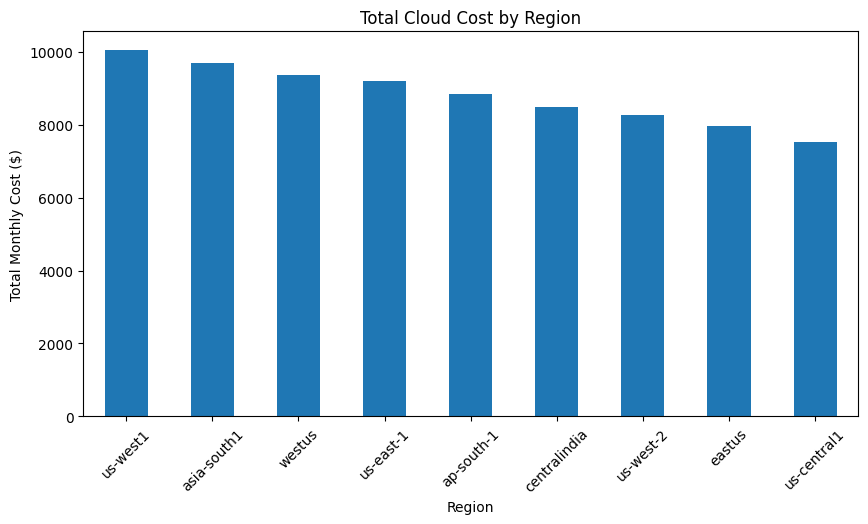

In [23]:
region_cost.plot(kind="bar", figsize=(10, 5))

plt.title("Total Cloud Cost by Region")
plt.xlabel("Region")
plt.ylabel("Total Monthly Cost ($)")
plt.xticks(rotation=45)

plt.show()

In [24]:
total_cost = df["Monthly_Cost"].sum()

print(f"Total Monthly Cloud Cost: ${total_cost:,.2f}")
print(f"Average Cost per Record: ${df['Monthly_Cost'].mean():,.2f}")
print(f"Number of Records: {len(df)}")

Total Monthly Cloud Cost: $79,395.61
Average Cost per Record: $158.79
Number of Records: 500


In [25]:
cost_threshold = df["Monthly_Cost"].quantile(0.90)

df["Optimization_Flag"] = df["Monthly_Cost"].apply(
    lambda x: "High Cost" if x >= cost_threshold else "Normal"
)

df["Optimization_Flag"].value_counts()

Optimization_Flag
Normal       450
High Cost     50
Name: count, dtype: int64

In [26]:
optimization_candidates = df[
    df["Optimization_Flag"] == "High Cost"
].sort_values("Monthly_Cost", ascending=False)

optimization_candidates[
    [
        "Account_ID",
        "Cloud_Provider",
        "Service",
        "Region",
        "Usage_Hours",
        "Monthly_Cost",
        "Optimization_Flag"
    ]
].head(20)

,Account_ID,Cloud_Provider,Service,Region,Usage_Hours,Monthly_Cost,Optimization_Flag
404,ACC-135,AWS,EC2,us-east-1,630,384.22,High Cost
159,ACC-140,Azure,Virtual Machines,centralindia,679,384.07,High Cost
10,ACC-146,Azure,Virtual Machines,westus,660,371.09,High Cost
262,ACC-105,Azure,Blob Storage,westus,719,369.23,High Cost
331,ACC-106,AWS,Lambda,us-east-1,630,363.15,High Cost
202,ACC-143,Azure,Azure SQL,westus,612,354.01,High Cost
373,ACC-132,AWS,Lambda,us-west-2,620,332.86,High Cost
249,ACC-105,Azure,Functions,westus,652,330.17,High Cost
104,ACC-106,GCP,Cloud Functions,asia-south1,714,328.89,High Cost
71,ACC-119,AWS,EC2,ap-south-1,670,325.55,High Cost


In [27]:
high_cost_summary = optimization_candidates["Monthly_Cost"].agg(
    ["count", "sum", "mean", "max"]
)

high_cost_summary

count       50.0000
sum      15077.9900
mean       301.5598
max        384.2200
Name: Monthly_Cost, dtype: float64

In [28]:
high_cost_by_provider = optimization_candidates.groupby(
    "Cloud_Provider"
)["Monthly_Cost"].agg(
    ["count", "sum", "mean"]
).sort_values("sum", ascending=False)

high_cost_by_provider

,count,sum,mean
Cloud_Provider,,,
Azure,18,5538.70,307.705556
AWS,16,4874.00,304.625000
GCP,16,4665.29,291.580625


In [29]:
potential_savings = optimization_candidates["Monthly_Cost"].sum() * 0.15

print(f"Potential Monthly Savings: ${potential_savings:,.2f}")
print(f"Potential Annual Savings: ${potential_savings * 12:,.2f}")

Potential Monthly Savings: $2,261.70
Potential Annual Savings: $27,140.38


In [30]:
current_high_cost = optimization_candidates["Monthly_Cost"].sum()
optimized_high_cost = current_high_cost - potential_savings

print(f"Current High-Cost Spending: ${current_high_cost:,.2f}")
print(f"Projected Spending After Optimization: ${optimized_high_cost:,.2f}")
print(f"Savings Percentage: 15%")

Current High-Cost Spending: $15,077.99
Projected Spending After Optimization: $12,816.29
Savings Percentage: 15%


In [31]:
high_cost_by_service = optimization_candidates.groupby(
    "Service"
)["Monthly_Cost"].agg(
    ["count", "sum", "mean"]
).sort_values("sum", ascending=False)

high_cost_by_service

,count,sum,mean
Service,,,
Azure SQL,7,2115.99,302.284286
EC2,6,1861.95,310.325000
Cloud SQL,6,1701.26,283.543333
Virtual Machines,5,1567.97,313.594000
Blob Storage,5,1524.57,304.914000
Cloud Storage,5,1447.89,289.578000
RDS,4,1170.56,292.640000
Lambda,3,984.98,328.326667
Cloud Functions,3,891.28,297.093333


In [32]:
high_cost_by_region = optimization_candidates.groupby(
    "Region"
)["Monthly_Cost"].agg(
    ["count", "sum", "mean"]
).sort_values("sum", ascending=False)

high_cost_by_region

,count,sum,mean
Region,,,
us-west1,8,2314.67,289.333750
westus,7,2292.82,327.545714
eastus,7,1975.68,282.240000
us-west-2,6,1732.47,288.745000
us-east-1,5,1622.67,324.534000
ap-south-1,5,1518.86,303.772000
asia-south1,5,1507.68,301.536000
centralindia,4,1270.20,317.550000
us-central1,3,842.94,280.980000


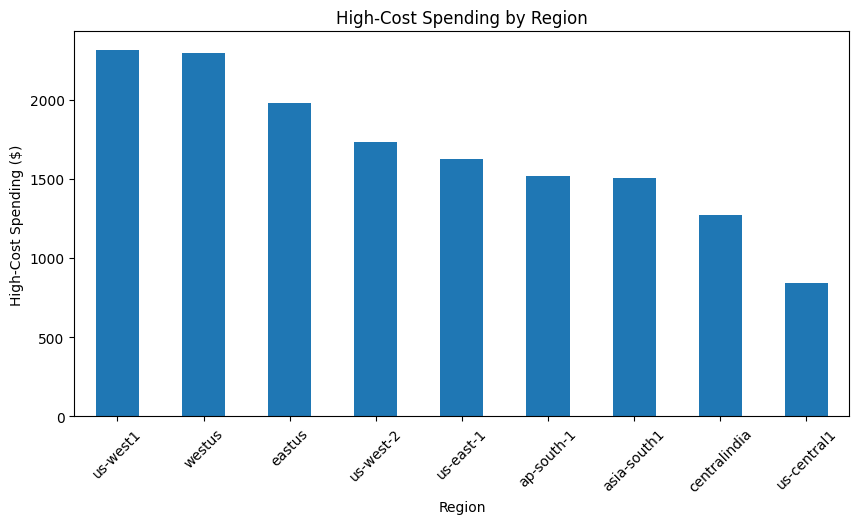

In [33]:
high_cost_by_region["sum"].plot(kind="bar", figsize=(10, 5))

plt.title("High-Cost Spending by Region")
plt.xlabel("Region")
plt.ylabel("High-Cost Spending ($)")
plt.xticks(rotation=45)

plt.show()

In [34]:
df["Recommendation"] = df["Optimization_Flag"].apply(
    lambda x: "Review for Optimization" if x == "High Cost"
    else "No Immediate Action"
)

df["Recommendation"].value_counts()

Recommendation
No Immediate Action        450
Review for Optimization     50
Name: count, dtype: int64

In [35]:
def get_recommendation(row):
    if row["Optimization_Flag"] != "High Cost":
        return "No Immediate Action"

    if row["Service"] in ["EC2", "Virtual Machines", "Compute Engine"]:
        return "Review Compute Usage"

    if row["Service"] in ["S3", "Blob Storage", "Cloud Storage"]:
        return "Review Storage Usage"

    if row["Service"] in ["RDS", "Azure SQL", "Cloud SQL"]:
        return "Review Database Usage"

    return "Review Service Usage"


df["Recommendation"] = df.apply(get_recommendation, axis=1)

df["Recommendation"].value_counts()

Recommendation
No Immediate Action      450
Review Database Usage     17
Review Compute Usage      13
Review Storage Usage      13
Review Service Usage       7
Name: count, dtype: int64

In [36]:
recommendation_summary = df[
    df["Optimization_Flag"] == "High Cost"
][[
    "Account_ID",
    "Cloud_Provider",
    "Service",
    "Region",
    "Monthly_Cost",
    "Recommendation"
]].sort_values("Monthly_Cost", ascending=False)

recommendation_summary.head(20)

,Account_ID,Cloud_Provider,Service,Region,Monthly_Cost,Recommendation
404,ACC-135,AWS,EC2,us-east-1,384.22,Review Compute Usage
159,ACC-140,Azure,Virtual Machines,centralindia,384.07,Review Compute Usage
10,ACC-146,Azure,Virtual Machines,westus,371.09,Review Compute Usage
262,ACC-105,Azure,Blob Storage,westus,369.23,Review Storage Usage
331,ACC-106,AWS,Lambda,us-east-1,363.15,Review Service Usage
202,ACC-143,Azure,Azure SQL,westus,354.01,Review Database Usage
373,ACC-132,AWS,Lambda,us-west-2,332.86,Review Service Usage
249,ACC-105,Azure,Functions,westus,330.17,Review Service Usage
104,ACC-106,GCP,Cloud Functions,asia-south1,328.89,Review Service Usage
71,ACC-119,AWS,EC2,ap-south-1,325.55,Review Compute Usage


In [37]:
recommendation_counts = df[
    df["Optimization_Flag"] == "High Cost"
]["Recommendation"].value_counts()

recommendation_counts

Recommendation
Review Database Usage    17
Review Compute Usage     13
Review Storage Usage     13
Review Service Usage      7
Name: count, dtype: int64

In [38]:
recommendation_cost = df[
    df["Optimization_Flag"] == "High Cost"
].groupby("Recommendation")["Monthly_Cost"].agg(
    ["count", "sum", "mean"]
).sort_values("sum", ascending=False)

recommendation_cost

,count,sum,mean
Recommendation,,,
Review Database Usage,17,4987.81,293.400588
Review Compute Usage,13,4054.78,311.906154
Review Storage Usage,13,3828.97,294.536154
Review Service Usage,7,2206.43,315.204286


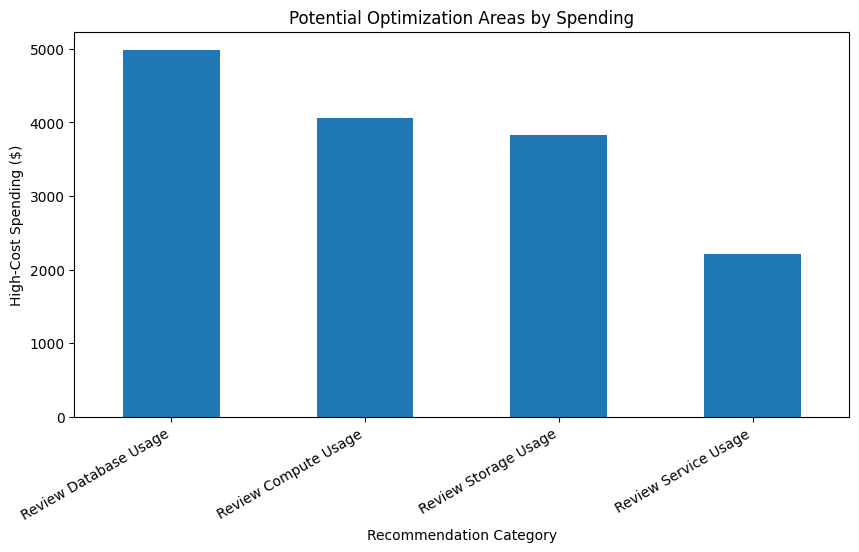

In [39]:
recommendation_cost["sum"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Potential Optimization Areas by Spending")
plt.xlabel("Recommendation Category")
plt.ylabel("High-Cost Spending ($)")
plt.xticks(rotation=30, ha="right")

plt.show()

In [40]:
print("========== CLOUD COST OPTIMIZATION SUMMARY ==========")
print(f"Total Records Analyzed: {len(df)}")
print(f"Total Monthly Cloud Cost: ${df['Monthly_Cost'].sum():,.2f}")
print(f"Average Cost per Record: ${df['Monthly_Cost'].mean():,.2f}")
print(f"High-Cost Records: {len(optimization_candidates)}")
print(f"High-Cost Spending: ${optimization_candidates['Monthly_Cost'].sum():,.2f}")
print(f"Potential Monthly Savings (15%): ${potential_savings:,.2f}")
print(f"Potential Annual Savings (15%): ${potential_savings * 12:,.2f}")

========== CLOUD COST OPTIMIZATION SUMMARY ==========
Total Records Analyzed: 500
Total Monthly Cloud Cost: $79,395.61
Average Cost per Record: $158.79
High-Cost Records: 50
High-Cost Spending: $15,077.99
Potential Monthly Savings (15%): $2,261.70
Potential Annual Savings (15%): $27,140.38


In [41]:
df.to_csv("../data/processed/cloud_cost_analysis.csv", index=False)

print("Analysis dataset saved successfully.")

Analysis dataset saved successfully.


In [42]:
optimization_candidates.to_csv(
    "../results/optimization_candidates.csv",
    index=False
)

print("Optimization candidates saved successfully.")

Optimization candidates saved successfully.
